# Chapter 7. Data Cleaning and Preparation

## 7.1 Handling Missing Data
- All of the descriptive statistics on pandas objects exclude missing data by default.
- For Numeric data, pandas uses the floating-point value **NaN** (Not a Number) to represent missing data.
- By refering to missing data as **NA**, which stands for *not available*. NA data may either be data that does not exist or that exists but was not observed.
- The built-in Python **None** value is also treated as NA in in object arrays:

In [1]:
import numpy as np
import pandas as pd

In [3]:
string_data = pd.Series(['aa', 'bb', np.nan, 'cc'])
string_data.isnull()

0    False
1    False
2     True
3    False
dtype: bool

In [4]:
string_data[0] = None
string_data.isnull()

0     True
1    False
2     True
3    False
dtype: bool

> 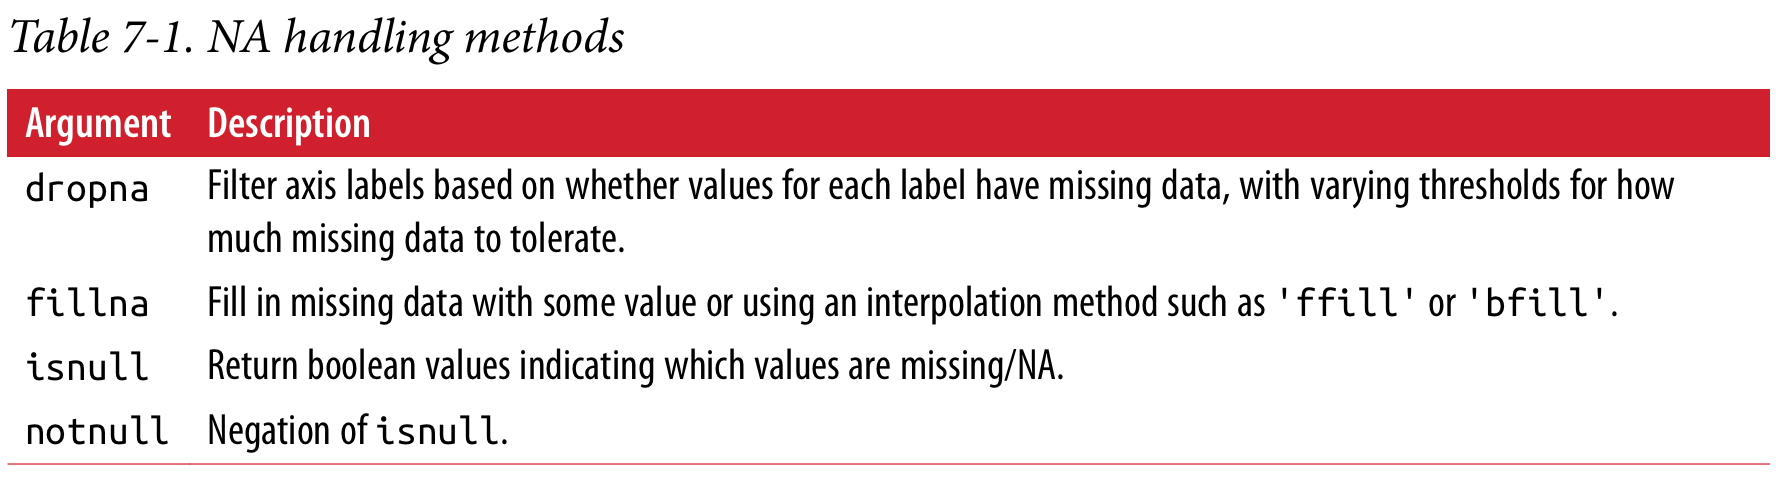

### Filtering Out Missing Data
> ***dropna*** : **On a Series**, it returns the Series with only the non-null data and index values:

In [10]:
data = pd.Series([1, np.nan, 3.5, np.nan, 7])
data.dropna()

0    1.0
2    3.5
4    7.0
dtype: float64

> **On a DataFrame**, *dropna* by default **drops any row containing a missing value** 

In [2]:
data = pd.DataFrame([[1.,6.5,3.],[1,np.nan,np.nan],
                    [np.nan,np.nan,np.nan],[np.nan,6.5,3]])
data

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


In [3]:
data.dropna()

,0,1,2
0,1.0,6.5,3.0


> - Passing **how = 'all'** will only drop rows that are all NA:

In [4]:
data.dropna(how='all')

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
3,NaN,6.5,3.0


> - To drop columns in the same way, pass **axis = 1**:

In [5]:
data[4] = np.nan
data

,0,1,2,4
0,1.0,6.5,3.0,NaN
1,1.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,6.5,3.0,NaN


In [6]:
data.dropna(how='all', axis = 1)

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


> - To keep only rows containing a certain number of observations -> Use ***thresh*** 

In [21]:
df = pd.DataFrame(np.random.randn(7,3))
df.iloc[:4, 1] = np.nan
df.iloc[:2, 2] = np.nan
df

,0,1,2
0,0.681552,NaN,NaN
1,1.869648,NaN,NaN
2,-0.563461,NaN,0.153989
3,-0.784937,NaN,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


In [22]:
df.dropna(thresh=3)

,0,1,2
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


### Filling in Missing Data
> - Calling *fillna* with a **dict**, you can use a different fill value for each column:

In [23]:
df.fillna({1:0.5, 2:0}) #return new object, 원 Df 변경 없음

,0,1,2
0,0.681552,0.500000,0.000000
1,1.869648,0.500000,0.000000
2,-0.563461,0.500000,0.153989
3,-0.784937,0.500000,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


In [24]:
df

,0,1,2
0,0.681552,NaN,NaN
1,1.869648,NaN,NaN
2,-0.563461,NaN,0.153989
3,-0.784937,NaN,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


> 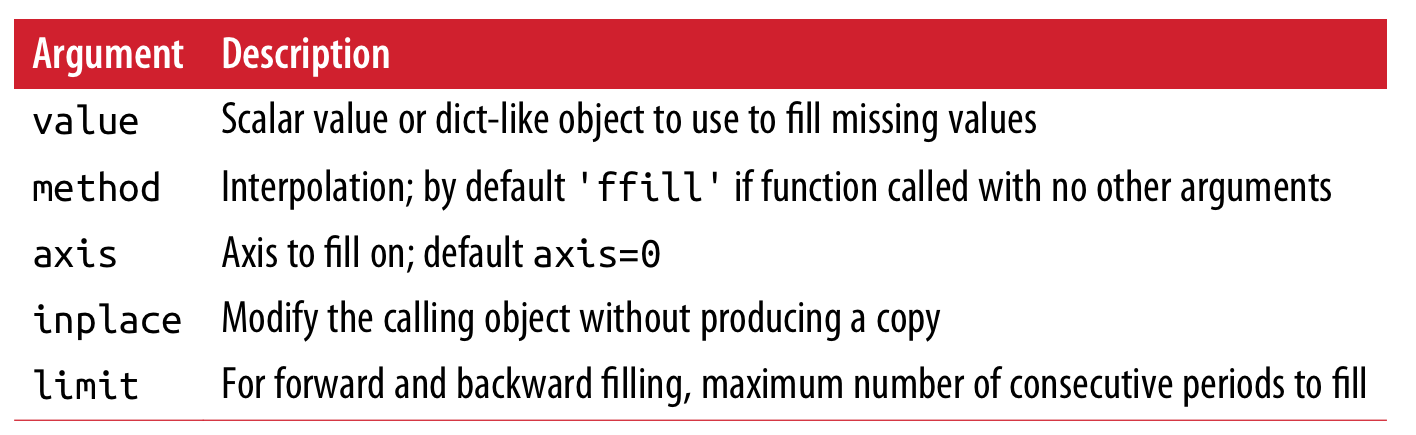

In [25]:
df.fillna(0, limit=2, inplace=True)
df # inplace 조건으로 원 DataFrame 변경

,0,1,2
0,0.681552,0.000000,0.000000
1,1.869648,0.000000,0.000000
2,-0.563461,NaN,0.153989
3,-0.784937,NaN,-0.199160
4,0.715697,0.408024,0.700945
5,0.720418,-0.053219,-0.118896
6,-1.350922,-0.867327,-2.085371


## 7.2 Data Transformation
### Removing Duplicates

In [2]:
data = pd.DataFrame({'k1':['one','two']*3 + ['two'],
                    'k2':[1,1,2,3,3,4,4]})
data

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4
6,two,4


> - The method ***duplicated*** **returns a boolean Series** indicating whether each row is a duplicate or not:
> - drop_duplicates **returns a DataFrame where the duplicated array is False**:

In [3]:
data.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6     True
dtype: bool

In [4]:
data.drop_duplicates()

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4


> - By default consider all of the columns; alternatively, you can specify any subset of them to detect duplicates.
> - Passing ***keep = 'last'*** will return the last one:

In [5]:
data['v1'] = range(7)
data.drop_duplicates(['k1'])

,k1,k2,v1
0,one,1,0
1,two,1,1


In [6]:
data.drop_duplicates(['k1', 'k2'], keep='last')

,k1,k2,v1
0,one,1,0
1,two,1,1
2,one,2,2
3,two,3,3
4,one,3,4
6,two,4,6


### Transforming Data Using a Function or Mapping

In [7]:
data = pd.DataFrame({'food':['bacon','pulled pork', 'bacon',
                            'Pastrami','corned beef','Bacon',
                            'pastrami','honey ham','nova lox'],
                    'ounces':[4,3,12,6,7.5,8,3,5,6]})
data

,food,ounces
0,bacon,4.0
1,pulled pork,3.0
2,bacon,12.0
3,Pastrami,6.0
4,corned beef,7.5
5,Bacon,8.0
6,pastrami,3.0
7,honey ham,5.0
8,nova lox,6.0


In [8]:
meat_to_animal = {'bacon':'pig','pulled pork':'pig',
                  'pastrami':'cow', 'corned beef':'cow',
                 'honey ham':'pig', 'nova lox':'salmon'}

> - The ***map* method on a Series** accepts a function or dict-like object containing a mapping
> - Using ***map*** is a convenient way to perform element-wise transformations and other data cleaning-related operations.

In [10]:
lowercased = data['food'].str.lower()
lowercased

0          bacon
1    pulled pork
2          bacon
3       pastrami
4    corned beef
5          bacon
6       pastrami
7      honey ham
8       nova lox
Name: food, dtype: object

In [11]:
data['animal'] = lowercased.map(meat_to_animal)
data

,food,ounces,animal
0,bacon,4.0,pig
1,pulled pork,3.0,pig
2,bacon,12.0,pig
3,Pastrami,6.0,cow
4,corned beef,7.5,cow
5,Bacon,8.0,pig
6,pastrami,3.0,cow
7,honey ham,5.0,pig
8,nova lox,6.0,salmon


In [12]:
data['food'].map(lambda x: meat_to_animal[x.lower()])
# meat_to_animal['Pastrami'.lower()] -> 'cow'

0       pig
1       pig
2       pig
3       cow
4       cow
5       pig
6       cow
7       pig
8    salmon
Name: food, dtype: object

### Replacing Values

In [2]:
data = pd.Series([1.,-999,2.,-999,-1000,3.])
data

0       1.0
1    -999.0
2       2.0
3    -999.0
4   -1000.0
5       3.0
dtype: float64

In [3]:
data.replace([-999, -1000], np.nan) # return new object, 원 데이터 변화 x

0    1.0
1    NaN
2    2.0
3    NaN
4    NaN
5    3.0
dtype: float64

> - To use a different replacement for each value, pass a list of substitutes:

In [4]:
data.replace([-999,-1000], [np.nan, 0])
# = data.replace({-999: np.nan, -1000: 0}) dict type

0    1.0
1    NaN
2    2.0
3    NaN
4    0.0
5    3.0
dtype: float64

### Renaming Axis Indexes
- Like values in a Series, **axis labels** can be similarly transformed by a function or mapping of some form to produce new, differently labeled objects.

In [5]:
data = pd.DataFrame(np.arange(12).reshape((3,4)), 
                    index=['Ohio','Colorado','New York'],
                   columns=['one','two','three','four'])

> - Like a Series, the axis indexes have a **map method**:
> - You can assign to index, modifying the DataFrame in-place:

In [8]:
transform = lambda x: x[:4].upper()
data.index.map(transform)

Index(['OHIO', 'COLO', 'NEW '], dtype='object')

In [11]:
data.index = data.index.map(transform) # 원 DataFrame 변경
data

,one,two,three,four
OHIO,0,1,2,3
COLO,4,5,6,7
NEW,8,9,10,11


> - Create a transformed version of a dataset without modifying the original : ***rename***
> - conjunction with a dict-like object providing new values for a subset of the axis labels:

In [15]:
data.rename(index=str.title, columns=str.upper)

,ONE,TWO,THREE,FOUR
Ohio,0,1,2,3
Colo,4,5,6,7
New,8,9,10,11


In [16]:
data.rename(index={'OHIO':'INDIANA'}, columns={'three':'peekaboo'})

,one,two,peekaboo,four
INDIANA,0,1,2,3
COLO,4,5,6,7
NEW,8,9,10,11


### Discretization and Binning
- Continuous data is often discretized or otherwise seperated into "bins" for analysis.

In [2]:
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]
bins = [18, 25, 35, 60, 100]

In [3]:
cats = pd.cut(ages, bins)
cats

[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (25, 35], (60, 100], (35, 60], (35, 60], (25, 35]]
Length: 12
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]

> - **Categorical object** : You can treat it like an array of strings indicating the bin name

In [4]:
cats.codes

array([0, 0, 0, 1, 0, 0, 2, 1, 3, 2, 2, 1], dtype=int8)

In [5]:
cats.categories

IntervalIndex([(18, 25], (25, 35], (35, 60], (60, 100]], dtype='interval[int64, right]')

> - Consistent with mathmatical notation for intervals, a **parenthesis** means that the side is ***open***, while the **square bracket** means it is ***closed(inclusive)***.

In [4]:
pd.cut(ages, [18, 26, 36, 61, 100], right=False)

[[18, 26), [18, 26), [18, 26), [26, 36), [18, 26), ..., [26, 36), [61, 100), [36, 61), [36, 61), [26, 36)]
Length: 12
Categories (4, interval[int64, left]): [[18, 26) < [26, 36) < [36, 61) < [61, 100)]

> - Pass your own **bin names** by passing a list or array to the ***labels*** option:

In [11]:
group_name = ['Youth','YoungAdult','MiddleAged','Senior']
pd.cut(ages, bins, labels=group_name)

['Youth', 'Youth', 'Youth', 'YoungAdult', 'Youth', ..., 'YoungAdult', 'Senior', 'MiddleAged', 'MiddleAged', 'YoungAdult']
Length: 12
Categories (4, object): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']

> - If you **pass an integer number of bins** to cut instead of explicit bin edge, it will compute equal-length bons based on the minimum and maximum values in the data

In [3]:
data = np.random.rand(20)
pd.cut(data, 4, precision=2) # limits the decimal precision

[(0.74, 0.98], (-0.00014, 0.25], (0.74, 0.98], (0.25, 0.49], (0.25, 0.49], ..., (-0.00014, 0.25], (0.49, 0.74], (0.25, 0.49], (-0.00014, 0.25], (0.25, 0.49]]
Length: 20
Categories (4, interval[float64, right]): [(-0.00014, 0.25] < (0.25, 0.49] < (0.49, 0.74] < (0.74, 0.98]]

> - A closely related functions, ***qcut***, bins the data based on sample **quantiles**.
> - Since ***qcut*** uses sample quantiles instead, by definition you will obtain roughly equal-size bins:

In [6]:
data = np.random.randn(1000) # nomally distributed
cats = pd.qcut(data, 4) # Cut into quartiles
cats

[(-3.0829999999999997, -0.681], (0.716, 2.886], (0.716, 2.886], (0.716, 2.886], (-0.0167, 0.716], ..., (0.716, 2.886], (-3.0829999999999997, -0.681], (0.716, 2.886], (-0.681, -0.0167], (-0.681, -0.0167]]
Length: 1000
Categories (4, interval[float64, right]): [(-3.0829999999999997, -0.681] < (-0.681, -0.0167] < (-0.0167, 0.716] < (0.716, 2.886]]

In [7]:
pd.value_counts(cats)

(-3.0829999999999997, -0.681]    250
(-0.681, -0.0167]                250
(-0.0167, 0.716]                 250
(0.716, 2.886]                   250
dtype: int64

> - Similar to cut you can pass your own quantiles (numbers between 0 and 1, inclusive)

In [8]:
pd.qcut(data, [0,0.1,0.5,0.9,1])

[(-1.266, -0.0167], (1.328, 2.886], (1.328, 2.886], (-0.0167, 1.328], (-0.0167, 1.328], ..., (-0.0167, 1.328], (-1.266, -0.0167], (-0.0167, 1.328], (-1.266, -0.0167], (-1.266, -0.0167]]
Length: 1000
Categories (4, interval[float64, right]): [(-3.0829999999999997, -1.266] < (-1.266, -0.0167] < (-0.0167, 1.328] < (1.328, 2.886]]

### Detecting and Filtering Outliers (이상치 처리)

In [11]:
data = pd.DataFrame(np.random.randn(1000,4))
data.describe()

,0,1,2,3
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.053920,0.031739,0.073692,-0.054281
std,1.015113,0.974351,0.971305,1.010856
min,-2.867871,-2.576754,-3.247569,-4.099429
25%,-0.667802,-0.629146,-0.581485,-0.728707
50%,0.046562,0.032641,0.074991,-0.079327
75%,0.784913,0.673857,0.697130,0.649189
max,2.902482,3.524877,2.870456,2.964402


> - To select all rows, you can use the ***any*** method on a boolean DataFrame:

In [12]:
data[(np.abs(data)>3).any(1)]

,0,1,2,3
345,-1.429112,3.524877,0.185618,-1.093674
610,0.394321,-0.455510,0.860941,-4.099429
648,0.292245,-0.610585,-3.247569,1.618078
934,0.815405,-0.359272,-0.143293,-3.037855
985,0.233526,3.193715,-0.633955,0.891774


In [14]:
# 위 데이터에 cap 씌우기
data[(np.abs(data)>3)] = np.sign(data)*3 # produce 1 and -1 values based on sign of data
data.describe()

,0,1,2,3
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.053920,0.031020,0.073939,-0.053143
std,1.015113,0.971996,0.970489,1.006931
min,-2.867871,-2.576754,-3.000000,-3.000000
25%,-0.667802,-0.629146,-0.581485,-0.728707
50%,0.046562,0.032641,0.074991,-0.079327
75%,0.784913,0.673857,0.697130,0.649189
max,2.902482,3.000000,2.870456,2.964402


### Permutation and Random Sampling

In [3]:
df = pd.DataFrame(np.arange(5*4).reshape((5,4)))
df

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15
4,16,17,18,19


In [4]:
sampler = np.random.permutation(5)
sampler

array([2, 3, 1, 4, 0])

In [5]:
df.take(sampler)

,0,1,2,3
2,8,9,10,11
3,12,13,14,15
1,4,5,6,7
4,16,17,18,19
0,0,1,2,3


> - To select a random subset without replacement, you can use the ***sample*** method on Series and DataFrame:
> - To generate a sample with replacement (to allow repeat choices), pass ***replace=True*** to *sample*:

In [8]:
df.sample(n=3)

,0,1,2,3
1,4,5,6,7
2,8,9,10,11
0,0,1,2,3


In [16]:
choices = pd.Series([5,7,-1,6,4])
draws = choices.sample(n=10, replace=True)
draws

3    6
2   -1
4    4
0    5
0    5
3    6
3    6
4    4
4    4
1    7
dtype: int64

### Computing Indicator/Dummy Variables
- Converting a categorical variable into a "dummy" or "indicator" matrix

In [2]:
df = pd.DataFrame({'key':['b','b','a','c','a','b'],
                  'data1': range(6)})
df

,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,b,5


In [3]:
pd.get_dummies(df['key'])

,a,b,c
0,0,1,0
1,0,1,0
2,1,0,0
3,0,0,1
4,1,0,0
5,0,1,0


In [5]:
dummies = pd.get_dummies(df['key'], prefix='key')
df_with_dummy = df[['data1']].join(dummies)
df_with_dummy

,data1,key_a,key_b,key_c
0,0,0,1,0
1,1,0,1,0
2,2,1,0,0
3,3,0,0,1
4,4,1,0,0
5,5,0,1,0


> - For multiple categories (아래 예시)

In [3]:
mnames = ['movie_id', 'title', 'genres']
movies = pd.read_table('Examples/movies.dat', sep='::',
                       header=None, names=mnames, 
                       encoding='latin1', engine='python')

In [4]:
movies

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [5]:
all_genres = []
for x in movies.genres:
    all_genres.extend(x.split('|'))

genres = pd.unique(all_genres)
genres

array(['Animation', "Children's", 'Comedy', 'Adventure', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Sci-Fi', 'Documentary', 'War', 'Musical', 'Mystery', 'Film-Noir',
       'Western'], dtype=object)

In [6]:
zero_matrix = np.zeros((len(movies), len(genres))) # ndarray
dummies = pd.DataFrame(zero_matrix, columns=genres) # DataFrame
dummies

,Animation,Children's,Comedy,Adventure,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Sci-Fi,Documentary,War,Musical,Mystery,Film-Noir,Western
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
for i, gen in enumerate(movies.genres):
    indices = dummies.columns.get_indexer(gen.split('|'))
    dummies.iloc[i, indices] = 1
dummies

,Animation,Children's,Comedy,Adventure,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Sci-Fi,Documentary,War,Musical,Mystery,Film-Noir,Western
0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3879,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3880,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3881,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
movies_windic = movies.join(dummies.add_prefix('Genre_'))
movies_windic

,movie_id,title,genres,Genre_Animation,Genre_Children's,Genre_Comedy,Genre_Adventure,Genre_Fantasy,Genre_Romance,Genre_Drama,...,Genre_Crime,Genre_Thriller,Genre_Horror,Genre_Sci-Fi,Genre_Documentary,Genre_War,Genre_Musical,Genre_Mystery,Genre_Film-Noir,Genre_Western
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men (1995),Comedy|Romance,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale (1995),Comedy|Drama,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II (1995),Comedy,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,3948,Meet the Parents (2000),Comedy,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3879,3949,Requiem for a Dream (2000),Drama,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3880,3950,Tigerland (2000),Drama,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3881,3951,Two Family House (2000),Drama,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> - A useful recipe for statistical application is to combine ***get_dummies*** with a discretization function like ***cut***:

In [14]:
np.random.seed(12345) # 교재와 값을 통일
values = np.random.rand(10)
values

array([0.92961609, 0.31637555, 0.18391881, 0.20456028, 0.56772503,
       0.5955447 , 0.96451452, 0.6531771 , 0.74890664, 0.65356987])

In [13]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
pd.get_dummies(pd.cut(values, bins))

,"(0.0, 0.2]","(0.2, 0.4]","(0.4, 0.6]","(0.6, 0.8]","(0.8, 1.0]"
0,0,0,0,0,1
1,0,1,0,0,0
2,1,0,0,0,0
3,0,1,0,0,0
4,0,0,1,0,0
5,0,0,1,0,0
6,0,0,0,0,1
7,0,0,0,1,0
8,0,0,0,1,0
9,0,0,0,1,0


> ## Skip
> ## 7.3 Extension Data Types
> ## 7.4 String Manipulation

## 7.5 Categorical Data

### Background and Motivation
- Many data systems have developed speciallized approaches for representing data with repeated values for more efficient storage and computation.
- In data warehousing, a best practice is **to use so-called dimension tables** containing the distinct values and storing the primary observations **as integer keys referecing the dimension table**:

In [3]:
values = pd.Series([0,1,0,0]*2)
dim = pd.Series(['apple','orange'])

> - We can use the ***take* method to restore the original Series of strings**:

In [4]:
dim.take(values)

0     apple
1    orange
0     apple
0     apple
0     apple
1    orange
0     apple
0     apple
dtype: object

- This representation as integer is called **the categorical or dictionary-encoded representation**.

> - The array of distinct values can be called the ***categories*, *dictionary*, or *levels*** of the data.
> - The **integer values** that reference the categories are called the ***category codes* or *simply codes***.

### Categorical Extension Type in pandas
- pandas has a special **Categorical** extension type for holding data that uses the **integer-based categorical representation or encoding**.
- Signicantly faster performance with lower memory use, especially for string data.
- **Categorical data need not be strings**. A categorical array can consist of any immutable value types.

In [6]:
fruits = ['apple','orange','apple','apple'] * 2
N = len(fruits)
rng = np.random.default_rng(seed=12345)

In [8]:
df = pd.DataFrame({'fruit':fruits, 'basket_id':np.arange(N),
                   'count':rng.integers(3,15,size=N),
                   'weight':rng.uniform(0,4,size=N)},
                  columns =['basket_id','fruit','count','weight'])
df

,basket_id,fruit,count,weight
0,0,apple,11,1.564438
1,1,orange,5,1.331256
2,2,apple,12,2.393235
3,3,apple,6,0.746937
4,4,apple,5,2.691024
5,5,orange,12,3.767211
6,6,apple,10,0.992983
7,7,apple,11,3.795525


> - Here, ***df['fruit']*** is an array of Python string objects. We can convert it to categorical by calling:

In [9]:
fruit_cat = df['fruit'].astype('category')
fruit_cat

0     apple
1    orange
2     apple
3     apple
4     apple
5    orange
6     apple
7     apple
Name: fruit, dtype: category
Categories (2, object): ['apple', 'orange']

> - The value for fruit_cat are now an instance of pandas.Categorical, which **you can access via the .array attribute**:

In [10]:
c = fruit_cat.array
type(c)

pandas.core.arrays.categorical.Categorical

In [11]:
c.categories

Index(['apple', 'orange'], dtype='object')

In [12]:
c.codes

array([0, 1, 0, 0, 0, 1, 0, 0], dtype=int8)

> - A useful trick **to get a mapping between codes and categories** is:

In [13]:
dict(enumerate(c.categories))

{0: 'apple', 1: 'orange'}

> - You can convert a DataFrame column to categorical by assigning the converted result:

In [18]:
df['fruit'] = df['fruit'].astype('category')
df['fruit']

0     apple
1    orange
2     apple
3     apple
4     apple
5    orange
6     apple
7     apple
Name: fruit, dtype: category
Categories (2, object): ['apple', 'orange']

> - You can also create ***pandas.Categorical*** directly **from other types of Python sequences**:

In [19]:
my_categories = pd.Categorical(['foo','bar','baz','foo','bar'])
my_categories

['foo', 'bar', 'baz', 'foo', 'bar']
Categories (3, object): ['bar', 'baz', 'foo']

> - If you have obtained categorical encoded data from another source, you can use the alternative ***from_codes*** constructor:
> - When using *from_codes* or any of the other constructors, you can **indicate that the categories have a meaningful ordering**:
> - An unordered categorical instance can be more ordered with ***as_ordered***:

In [2]:
categories = ['foo','bar','baz']
codes = [0,1,2,0,0,1]

In [3]:
my_cat_2 = pd.Categorical.from_codes(codes, categories)
my_cat_2

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo', 'bar', 'baz']

In [4]:
ordered_cat = pd.Categorical.from_codes(codes, categories, 
                                         ordered=True)
ordered_cat

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo' < 'bar' < 'baz']

In [5]:
my_cat_2.as_ordered()

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo' < 'bar' < 'baz']

### Computations with Categoricals
- Some parts of pandas, like the ***groupby*** function, **perform better** when working with categoricals.
- Because the underlying algorithms **use the integer_based codes array instead of an array of strings**.

In [6]:
rng = np.random.default_rng(seed=12345)
draws = rng.standard_normal(1000)
draws[:5]

array([-1.42382504,  1.26372846, -0.87066174, -0.25917323, -0.07534331])

In [7]:
bins = pd.qcut(draws, 4)
bins

[(-3.121, -0.675], (0.687, 3.211], (-3.121, -0.675], (-0.675, 0.0134], (-0.675, 0.0134], ..., (0.0134, 0.687], (0.0134, 0.687], (-0.675, 0.0134], (0.0134, 0.687], (-0.675, 0.0134]]
Length: 1000
Categories (4, interval[float64, right]): [(-3.121, -0.675] < (-0.675, 0.0134] < (0.0134, 0.687] < (0.687, 3.211]]

In [8]:
bins = pd.qcut(draws, 4, labels=['Q1','Q2','Q3','Q4'])
bins

['Q1', 'Q4', 'Q1', 'Q2', 'Q2', ..., 'Q3', 'Q3', 'Q2', 'Q3', 'Q2']
Length: 1000
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']

> - We can use *groupby* **to extract some summary statistics**: 

In [9]:
bins = pd.Series(bins, name='quartile')
bins

0      Q1
1      Q4
2      Q1
3      Q2
4      Q2
       ..
995    Q3
996    Q3
997    Q2
998    Q3
999    Q2
Name: quartile, Length: 1000, dtype: category
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']

In [20]:
result = (pd.Series(draws).groupby(bins)
 .agg(['counsnsnsnmot','min','max']).reset_index())
# 하나씩 추가하면서 결과 확인해 볼 것
# 오른쪽의 괄호는 행바꿈 적용하기 위해 사용한 것임
result

,quartile,count,min,max
0,Q1,250,-3.119609,-0.678494
1,Q2,250,-0.673305,0.008009
2,Q3,250,0.018753,0.686183
3,Q4,250,0.688282,3.211418


### Categorical Methods

In [3]:
s = pd.Series(['a','b','c','d']*2)
cat_s = s.astype('category')
cat_s

0    a
1    b
2    c
3    d
4    a
5    b
6    c
7    d
dtype: category
Categories (4, object): ['a', 'b', 'c', 'd']

In [29]:
b = cat_s.array
type(b) # pandas.core.array.categorical.Categorical
b.codes # ndarray 데이터 형식
b.categories # Index 형식

Index(['a', 'b', 'c', 'd'], dtype='object')

In [30]:
c = cat_s.cat
type(c) # pandas.core.arrays.categorical.CategoricalAccessor
c.codes # Series 데이터 형식
c.categories # Index 형식

Index(['a', 'b', 'c', 'd'], dtype='object')

> - We can use the ***set_categories*** method **to chage the category index**:

In [32]:
actual_categories = ['a','b','c','d','e']
cat_s2 = cat_s.cat.set_categories(actual_categories)
cat_s2

0    a
1    b
2    c
3    d
4    a
5    b
6    c
7    d
dtype: category
Categories (5, object): ['a', 'b', 'c', 'd', 'e']

In [33]:
cat_s.value_counts()

a    2
b    2
c    2
d    2
dtype: int64

In [34]:
cat_s2.value_counts()

a    2
b    2
c    2
d    2
e    0
dtype: int64

> - ***remove_unused_categories*** : To trim unobserved categories: 

In [36]:
cat_s3 = cat_s[cat_s.isin(['a','b'])]
cat_s3

0    a
1    b
4    a
5    b
dtype: category
Categories (4, object): ['a', 'b', 'c', 'd']

In [37]:
cat_s3.cat.remove_unused_categories()

0    a
1    b
4    a
5    b
dtype: category
Categories (2, object): ['a', 'b']

> Categorical methods for Series in pandas
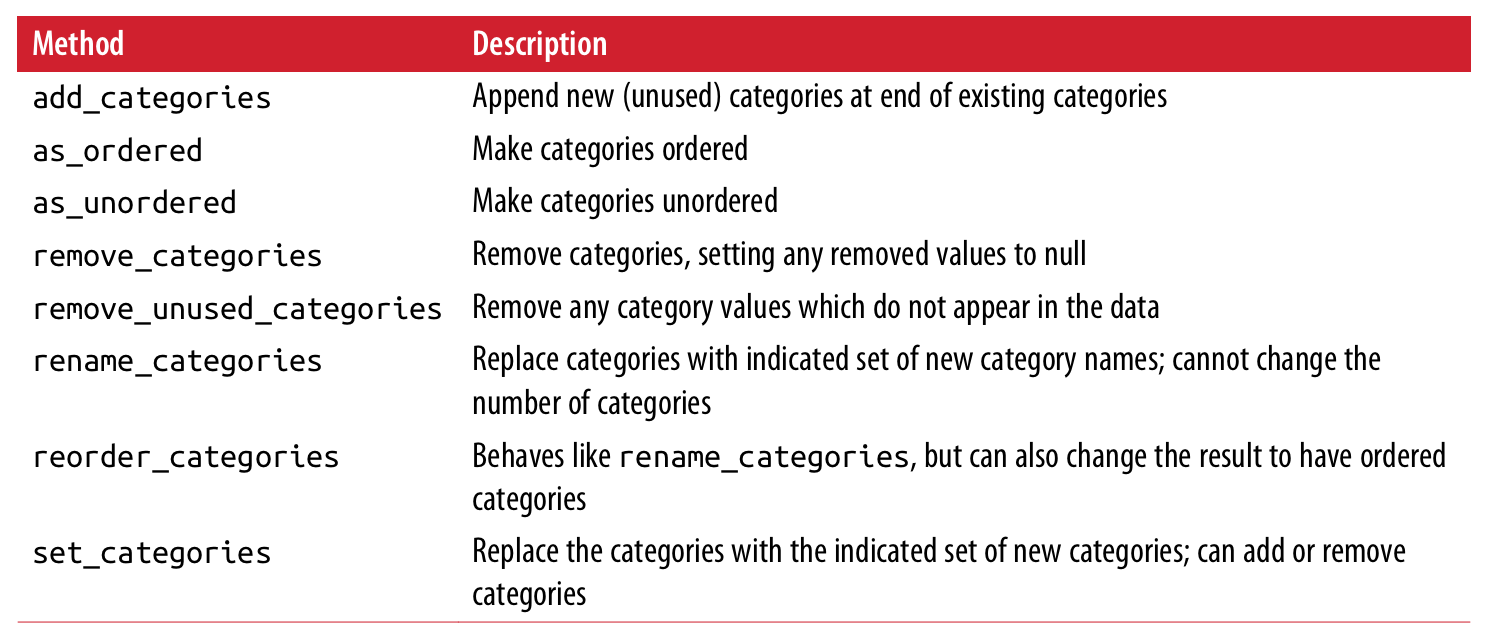

> - When you are using statistics or machine learning tools, you'll often **transform categorical data into *dummy variables***, also known as ***one-hot encoding***.
> - ***pandas.get_dummies*** : Converting one-dimensional categorical data into a DataFrame containing the dummy variable:

In [38]:
cat_s = pd.Series(['a','b','c','d']*2, dtype='category')
pd.get_dummies(cat_s)

,a,b,c,d
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1
4,1,0,0,0
5,0,1,0,0
6,0,0,1,0
7,0,0,0,1
